# 2 · Coupled PDEs: galvanostatic transport in a binary electrolyte

This notebook solves a small but real **system of coupled, nonlinear PDEs** from electrochemistry: diffusion and migration of a binary salt between two parallel electrodes when a constant current is switched on. It follows the dilute-solution theory of Newman & Thomas-Alyea, *Electrochemical Systems*, ch. 11.

The workflow is the one you would use for your own model:

1. write down the governing equations and boundary conditions;
2. discretize them with finite volumes and implicit time stepping, so that each time step is a nonlinear system in the BAND form;
3. code the residual $\mathbf F$ and its Jacobian blocks $\mathsf A,\mathsf B,\mathsf D$ (and verify them with `check_jacobian`);
4. march in time with `bs.newton`, then **validate** the result against an analytic solution.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import bandsolver as bs

# Plot style: categorical colours in fixed order, an ordinal blue ramp for time series,
# neutral ink for text, thin marks and a recessive grid.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]   # light -> dark
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e6e5e0"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": INK2, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK2, "ytick.color": INK2, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "lines.markersize": 6, "legend.frameon": False,
    "figure.dpi": 110, "font.size": 10, "axes.titlesize": 11,
})
print("bandsolver", bs.__version__, "| backends:", bs.BACKENDS)

bandsolver 0.1.0 | backends: ('cpp', 'fortran')


## 1. The physical problem

A 1:1 salt (charges $z_+ = +1$, $z_- = -1$) fills the gap $0 \le x \le L$ between two electrodes. At $t=0$ a constant current density $I$ is switched on, flowing in the $+x$ direction through the solution. The **cation** takes part in the electrode reactions: it is released at $x=0$ and consumed at $x=L$, as for Li⁺ between two lithium-metal electrodes. The **anion** does not react, so it cannot cross either electrode.

The salt therefore piles up near $x=0$ and depletes near $x=L$, and a potential gradient develops in the solution.

### Governing equations

Under dilute-solution theory, each ion's flux combines diffusion with migration in the electric field. The mobility is given by the Nernst–Einstein relation, $u_i = D_i/RT$:

$$
N_\pm = -D_\pm\left(\frac{\partial c_\pm}{\partial x} \pm c_\pm\,\frac{\partial \phi}{\partial x}\right),
\qquad \phi = \frac{F\Phi}{RT}\ \ (\text{dimensionless potential}).
$$

**Electroneutrality** requires $c_+ = c_- \equiv c$, so the unknowns are just the salt concentration $c(x,t)$ and the potential $\phi(x,t)$. Each ion obeys a material balance:

$$
\boxed{\;\frac{\partial c}{\partial t} = -\frac{\partial N_-}{\partial x},\qquad
\frac{\partial c}{\partial t} = -\frac{\partial N_+}{\partial x}\;}
\qquad\text{with}\qquad
N_\pm = -D_\pm\left(\frac{\partial c}{\partial x} \pm c\,\frac{\partial \phi}{\partial x}\right).
$$

These are two coupled PDEs, nonlinear through the migration term $c\,\partial\phi/\partial x$. The current density is $i = F(N_+ - N_-)$.

### Boundary and initial conditions

$$
\begin{aligned}
&x = 0: && N_- = 0, \quad N_+ = I/F, \\
&x = L: && N_- = 0, \quad N_+ = I/F, \\
&t = 0: && c = c_0 .
\end{aligned}
$$

The equations involve only $\partial\phi/\partial x$, so $\phi$ is determined only up to a constant. We fix it with a **reference** $\phi(L) = 0$. That condition takes the place of one redundant equation: the cation boundary flux at $x=L$ is already implied by current conservation, since subtracting the two balances gives $\partial i/\partial x = 0$.

### An analytic solution to check against

Eliminating $\phi$ between the two balances gives the classic binary-electrolyte result. The salt obeys a single diffusion equation with the **salt diffusivity** $D$, and the fraction of current carried by the cation is its **transference number** $t_+$:

$$
\frac{\partial c}{\partial t} = D\,\frac{\partial^2 c}{\partial x^2},\qquad
D = \frac{2D_+D_-}{D_+ + D_-},\qquad t_+ = \frac{D_+}{D_+ + D_-},
\qquad -D\,\frac{\partial c}{\partial x}\Big|_{x=0,L} = q \equiv \frac{(1-t_+)\,I}{F}.
$$

With a uniform initial concentration, separation of variables gives

$$
c(x,t) = c_0 + \frac{q}{D}\left(\frac L2 - x\right)
\;-\; \sum_{n\ \text{odd}} \frac{4qL}{D\,n^2\pi^2}\,\cos\frac{n\pi x}{L}\;e^{-n^2\pi^2 D t/L^2}.
$$

At steady state the concentration profile is **linear**. In addition, $N_- = 0$ everywhere, which forces $\partial c/\partial x = c\,\partial\phi/\partial x$, i.e. $\phi = \ln c + \text{const}$.

We will **not** solve this reduced equation. We solve the full coupled $(c,\phi)$ system, then check it against both of these results.

In [2]:
F, R, T = 96485.33212, 8.314462618, 298.15      # C/mol, J/(mol K), K
Dp, Dm = 1.0e-9, 2.0e-9                          # cation / anion diffusivity, m^2/s
L = 100e-6                                       # electrode gap, m
c0 = 100.0                                       # initial concentration, mol/m^3 (0.1 M)
I = 100.0                                        # applied current density, A/m^2

D = 2 * Dp * Dm / (Dp + Dm)                      # salt diffusivity
tp = Dp / (Dp + Dm)                              # cation transference number
q = (1 - tp) * I / F                             # salt flux at the walls
tau = L**2 / D                                   # diffusion time scale
print(f"D = {D:.3e} m^2/s,  t+ = {tp:.3f},  tau = L^2/D = {tau:.2f} s")
print(f"steady concentration range: {c0 - q * L / (2 * D):.1f} .. {c0 + q * L / (2 * D):.1f} mol/m^3")
print(f"limiting current (c -> 0 at x = L): {2 * F * D * c0 / ((1 - tp) * L):.0f} A/m^2")

def c_analytic(x, t, terms=400):
    c = c0 + (q / D) * (L / 2 - x)
    n = np.arange(1, 2 * terms, 2)[:, None]
    return c - np.sum(4 * q * L / (D * n**2 * np.pi**2) * np.cos(n * np.pi * x / L)
                      * np.exp(-n**2 * np.pi**2 * D * t / L**2), axis=0)

D = 1.333e-09 m^2/s,  t+ = 0.333,  tau = L^2/D = 7.50 s
steady concentration range: 74.1 .. 125.9 mol/m^3
limiting current (c -> 0 at x = L): 386 A/m^2


## 2. Discretization

We use $n_j$ nodes $x_j = jh$, $h = L/(n_j-1)$, with **control volumes** centred on the nodes. Interior volumes have width $V_j = h$; the two boundary volumes are half-width, $V_0 = V_{n_j-1} = h/2$. Fluxes are evaluated at the faces $j+\tfrac12$ between neighbouring nodes, with the concentration in the migration term taken as the face average:

$$
N_{\pm,\,j+\frac12} = -D_\pm\left(\frac{c_{j+1}-c_j}{h} \pm \bar c_{j+\frac12}\,\frac{\phi_{j+1}-\phi_j}{h}\right),
\qquad \bar c_{j+\frac12} = \tfrac12\,(c_j + c_{j+1}).
$$

**Implicit (backward) Euler** in time from $c^{\text{old}}$ to $c$ over $\Delta t$ gives, for each ion and each control volume,

$$
F_{\pm,j} = V_j\,\frac{c_j - c_j^{\text{old}}}{\Delta t} + N_{\pm,\,j+\frac12} - N_{\pm,\,j-\frac12} = 0 .
$$

In the boundary volumes the outer face flux is replaced by the boundary condition: $N_{+}=I/F$ and $N_-=0$ at both walls.

This scheme conserves exactly: summing the anion equations shows that the total salt $\sum_j V_j c_j$ never changes, just as in the continuous problem.

### Mapping onto BAND

Each node carries $n = 2$ unknowns and $2$ equations:

$$
\mathbf c_j = \begin{pmatrix} c_j \\ \phi_j \end{pmatrix},\qquad
\mathbf F_j = \begin{pmatrix} F_{-,j} \ \ (\text{anion balance}) \\ F_{+,j} \ \ (\text{cation balance}) \end{pmatrix},
\qquad\text{except}\qquad F_{+,\,n_j-1} \to \phi_{n_j-1} \ \ (\text{reference}).
$$

Each face flux depends on the four values $(c_j, \phi_j, c_{j+1}, \phi_{j+1})$. Its partial derivatives are

$$
\frac{\partial N_{\pm}}{\partial c_j} = -D_\pm\!\left(-\frac1h \pm \frac{\phi_{j+1}-\phi_j}{2h}\right),\quad
\frac{\partial N_{\pm}}{\partial c_{j+1}} = -D_\pm\!\left(\frac1h \pm \frac{\phi_{j+1}-\phi_j}{2h}\right),\quad
\frac{\partial N_{\pm}}{\partial \phi_j} = \pm\frac{D_\pm\,\bar c}{h} = -\frac{\partial N_{\pm}}{\partial \phi_{j+1}} .
$$

The right face of node $j$ enters $\mathbf F_j$ with a $+$ sign. Its derivatives with respect to node $j$ go into $\mathsf B_j$, and those with respect to node $j+1$ into $\mathsf D_j$. The left face enters with a $-$ sign, contributing to $\mathsf B_j$ and to $\mathsf A_j$ (for node $j-1$). The accumulation term adds $V_j/\Delta t$ to the $\partial/\partial c_j$ entry of $\mathsf B_j$.

The fill function below is a direct, vectorized transcription of these formulas.

In [3]:
def face_flux(c, phi, z, Dz, h):
    """Flux at every interior face j+1/2 and its derivatives w.r.t. (c_j, c_j+1, phi_j, phi_j+1)."""
    cl, cr, pl, pr = c[:-1], c[1:], phi[:-1], phi[1:]
    cbar, dphi = 0.5 * (cl + cr), pr - pl
    N = -Dz * ((cr - cl) / h + z * cbar * dphi / h)
    dN_dcl = -Dz * (-1 / h + z * dphi / (2 * h))
    dN_dcr = -Dz * (1 / h + z * dphi / (2 * h))
    dN_dpl = Dz * z * cbar / h
    return N, dN_dcl, dN_dcr, dN_dpl, -dN_dpl

def make_fill(c_old, dt):
    """Residual and Jacobian blocks for one implicit-Euler step from c_old."""
    nj = c_old.size
    h = L / (nj - 1)
    V = np.full(nj, h); V[0] = V[-1] = h / 2

    def fill(u):
        c, phi = u[:, 0], u[:, 1]
        A = np.zeros((nj, 2, 2)); B = np.zeros((nj, 2, 2)); Dk = np.zeros((nj, 2, 2)); Fr = np.zeros((nj, 2))
        # row 0: anion balance (z = -1, wall flux 0); row 1: cation balance (z = +1, wall flux I/F)
        for row, (z, Dz, wall_flux) in enumerate([(-1, Dm, 0.0), (+1, Dp, I / F)]):
            N, dcl, dcr, dpl, dpr = face_flux(c, phi, z, Dz, h)
            Fr[:, row] = V * (c - c_old) / dt                  # accumulation
            B[:, row, 0] += V / dt
            Fr[:-1, row] += N                                  # right face of nodes 0..nj-2
            B[:-1, row, 0] += dcl; B[:-1, row, 1] += dpl
            Dk[:-1, row, 0] += dcr; Dk[:-1, row, 1] += dpr
            Fr[1:, row] -= N                                   # left face of nodes 1..nj-1
            B[1:, row, 0] -= dcr; B[1:, row, 1] -= dpr
            A[1:, row, 0] -= dcl; A[1:, row, 1] -= dpl
            Fr[0, row] -= wall_flux                            # flux entering at x = 0
            Fr[-1, row] += wall_flux                           # flux leaving at x = L
        Fr[-1, 1] = phi[-1]                                    # reference phi(L) = 0 replaces
        A[-1, 1, :] = 0.0; B[-1, 1, :] = [0.0, 1.0]            # the redundant cation balance
        return A, B, Dk, -Fr                                   # G = -F
    return fill

### Verify the Jacobian before using it

The blocks were derived by hand, so we check them against finite differences at an arbitrary, non-trivial state. This takes one line and catches most derivation and indexing mistakes.

In [4]:
nj = 81
x = np.linspace(0, L, nj)
u_test = np.column_stack([c0 * (1 + 0.2 * np.sin(3 * x / L)), 0.5 * np.cos(2 * x / L)])
check = bs.check_jacobian(make_fill(np.full(nj, c0), dt=0.01), u_test)
print(f"check_jacobian max score = {check.max_error:.1e}   (correct: ~1e-9 .. 1e-5; bug: > 1e-3)")

check_jacobian max score = 6.3e-10   (correct: ~1e-9 .. 1e-5; bug: > 1e-3)


## 3. Time integration

Time stepping lives in user code: each step is a call to `bs.newton` with a fill function built from the previous state. The problem is only mildly nonlinear, so Newton needs only 1–3 iterations per step.

In [5]:
def simulate(nj, dt, t_out, backend="cpp"):
    """March from c = c0, phi = 0 and return the state at each time in t_out."""
    u = np.zeros((nj, 2)); u[:, 0] = c0
    t, out, iters = 0.0, {}, []
    for t_target in sorted(t_out):
        while t < t_target - 1e-12:
            res = bs.newton(make_fill(u[:, 0].copy(), dt), u, backend=backend)
            u, t = res.c, t + dt
            iters.append(res.iterations)
        out[t_target] = u.copy()
    return out, iters

times = [0.25, 1.0, 2.5, 6.0, 20.0]
states, iters = simulate(nj, dt=0.01, t_out=times)
print(f"{len(iters)} time steps, Newton iterations per step: min {min(iters)}, max {max(iters)}")
h = L / (nj - 1); V = np.full(nj, h); V[0] = V[-1] = h / 2
print(f"salt inventory drift: {abs(np.sum(V * states[20.0][:, 0]) / L - c0):.1e} mol/m^3 (conserved)")

2000 time steps, Newton iterations per step: min 1, max 3
salt inventory drift: 0.0e+00 mol/m^3 (conserved)


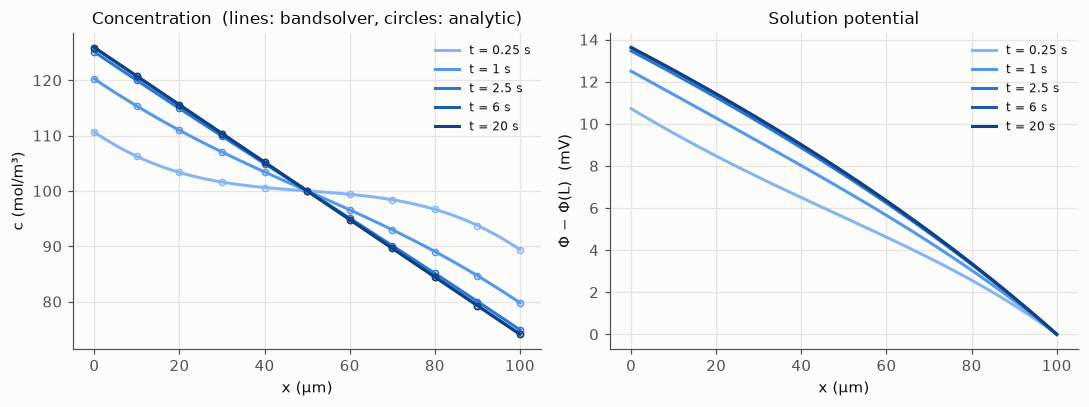

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8))
xm = x * 1e6
for t_k, color in zip(times, RAMP):
    c_num, phi_num = states[t_k][:, 0], states[t_k][:, 1]
    ax1.plot(xm, c_num, color=color, label=f"t = {t_k:g} s")
    ax1.plot(xm[::8], c_analytic(x, t_k)[::8], "o", color=color, markersize=4, markerfacecolor="none")
    ax2.plot(xm, phi_num * R * T / F * 1e3, color=color, label=f"t = {t_k:g} s")
ax1.set_xlabel("x (µm)"); ax1.set_ylabel("c (mol/m³)")
ax1.set_title("Concentration  (lines: bandsolver, circles: analytic)")
ax1.legend(fontsize=8, loc="upper right")
ax2.set_xlabel("x (µm)"); ax2.set_ylabel("Φ − Φ(L)  (mV)")
ax2.set_title("Solution potential")
ax2.legend(fontsize=8, loc="upper right")
fig.tight_layout(); plt.show()

Salt accumulates at the electrode that releases cations ($x=0$) and depletes at the one that consumes them ($x=L$). The profile relaxes to the straight line predicted by the analytic solution within a few time constants $\tau/\pi^2 \approx 0.76$ s. The numerical profiles (lines) lie on the analytic series (circles) at every time.

The potential needed to drive the current grows as the concentration gradient develops. Part of the change is ohmic, and part is a diffusion potential that the reduced equation cannot see. The coupled solve gives it directly.

## 4. Validation

### Time-step convergence

Backward Euler is first-order accurate in time, so halving $\Delta t$ should halve the error. The reference is the analytic series, and a fine mesh keeps the spatial error negligible.

dt =  0.1000 s   max |c - c_analytic| at t = 2 s: 2.612e-01 mol/m^3   observed order nan
dt =  0.0500 s   max |c - c_analytic| at t = 2 s: 1.309e-01 mol/m^3   observed order 1.00
dt =  0.0250 s   max |c - c_analytic| at t = 2 s: 6.557e-02 mol/m^3   observed order 1.00
dt =  0.0125 s   max |c - c_analytic| at t = 2 s: 3.288e-02 mol/m^3   observed order 1.00


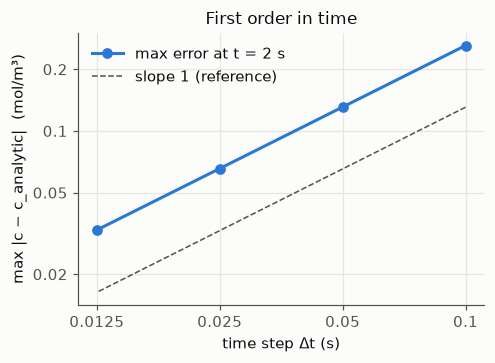

In [7]:
dts = [0.1, 0.05, 0.025, 0.0125]
xf = np.linspace(0, L, 161)
errs = []
for dt in dts:
    st, _ = simulate(161, dt, [2.0])
    errs.append(np.abs(st[2.0][:, 0] - c_analytic(xf, 2.0)).max())
for dt, e, o in zip(dts, errs, [np.nan] + list(np.log2(np.array(errs[:-1]) / np.array(errs[1:])))):
    print(f"dt = {dt:7.4f} s   max |c - c_analytic| at t = 2 s: {e:.3e} mol/m^3   observed order {o:.2f}")

fig, ax = plt.subplots(figsize=(4.6, 3.4))
ax.loglog(dts, errs, "o-", color=BLUE, label="max error at t = 2 s")
ax.loglog(dts, 0.5 * errs[0] * np.array(dts) / dts[0], color=INK2, linewidth=1, linestyle="--",
          label="slope 1 (reference)")
ax.set_xticks(dts, [f"{d:g}" for d in dts]); ax.set_yticks([0.02, 0.05, 0.1, 0.2], ["0.02", "0.05", "0.1", "0.2"])
ax.minorticks_off()
ax.set_xlabel("time step Δt (s)"); ax.set_ylabel("max |c − c_analytic|  (mol/m³)")
ax.set_title("First order in time"); ax.legend(); fig.tight_layout(); plt.show()

### Steady state

After many time constants the numerical solution should reach the analytic steady state. Three quantities are checked:

- the concentration profile should be exactly linear: $c = c_0 + \frac{q}{D}\left(\frac L2 - x\right)$;
- the anion flux should vanish everywhere, which makes $\phi - \ln c$ constant;
- the total potential drop across the cell should equal $\frac{RT}{F}\ln\frac{c(0)}{c(L)}$.

In [8]:
st, _ = simulate(nj, dt=0.25, t_out=[60.0])
c_ss, phi_ss = st[60.0][:, 0], st[60.0][:, 1]
lin = c0 + (q / D) * (L / 2 - x)
print(f"max |c - linear profile|        = {np.abs(c_ss - lin).max():.1e} mol/m^3")
print(f"spread of (phi - ln c)          = {np.ptp(phi_ss - np.log(c_ss)):.1e}   (O(h^2) discretization error)")
dPhi = (phi_ss[0] - phi_ss[-1]) * R * T / F
print(f"cell potential drop             = {dPhi * 1e3:.3f} mV;  (RT/F) ln(c(0)/c(L)) = "
      f"{R * T / F * np.log(c_ss[0] / c_ss[-1]) * 1e3:.3f} mV")

max |c - linear profile|        = 1.4e-14 mol/m^3
spread of (phi - ln c)          = 2.1e-06   (O(h^2) discretization error)
cell potential drop             = 13.625 mV;  (RT/F) ln(c(0)/c(L)) = 13.625 mV


The coupled finite-volume solution reproduces the linear steady profile to round-off, because a linear $c$ satisfies the discrete equations exactly. The $\phi = \ln c$ relation holds to the expected $O(h^2)$ discretization error.

## Takeaways

- A system of **coupled PDEs** becomes a BAND problem once each time step is written as $\mathbf F_j(\mathbf c_{j-1},\mathbf c_j,\mathbf c_{j+1}) = 0$ with a few unknowns per node. Here there were two: $c$ and $\phi$.
- **Algebraic conditions**, such as the potential reference, simply replace a row. The library does not distinguish differential from algebraic equations.
- Check any hand-written Jacobian with `bs.check_jacobian`. Alternatively, write only the residual and use `bs.newton_fd`, which the [next notebook](03_porous_electrode.ipynb) does.

**Try it:** raise `I` towards the limiting current printed above. The concentration at $x=L$ approaches zero, the potential diverges logarithmically, and Newton needs more iterations. Past the limiting current the concentration would go negative: the physics needs a different boundary condition, such as a potentiostatic one.